# Supervised Fine-Tuning with Gemini 2.5 Flash - Interactive Lab



### What We will Build

- ✅ A complete fine-tuning pipeline from data prep to evaluation
- ✅ A custom Gemini model optimized for summarization
- ✅ Evaluation framework using ROUGE metrics
- ✅ Understanding of training metrics and how to interpret them


## Task 1: Import libraries and install packages

First, let's install the libraries we need for this project along with the Google AI development libraries and necessary data processing, evaluation, and visualization tools.

In [1]:
%pip install google-cloud-aiplatform google-genai

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install jsonlines rouge-score tqdm plotly

Note: you may need to restart the kernel to use updated packages.


**Note:** Please restart the kernel by clicking **Kernel > Restart Kernel**.

In [1]:
import time
import sys

from google import genai
from google.cloud import aiplatform
from google.cloud.aiplatform.metadata import context
from google.cloud.aiplatform.metadata import utils as metadata_utils
from google.genai import types

import vertexai
import jsonlines
import pandas as pd
import numpy as np

import plotly.graph_objects as go
from plotly.subplots import make_subplots

from rouge_score import rouge_scorer
from tqdm import tqdm

## Task 2: Configure your project and create a storage bucket

Now let's configure the notebook with your specific project details and create a Cloud Storage bucket. 

### Initialize the SDKs

You will start by initializing the Vertex AI and Generative AI SDKs. This establishes the connection between your notebook environment and your Google Cloud project, allowing you to use Google's AI services.


**Define PROJECT_ID**

In [2]:
PROJECT_ID = os.getenv("PROJECT_ID", "your-gcp-project-id")
REGION = "us-central1"

**Initilize Vertex AI and Gen AI SDK**

In [3]:
# Initialize both Vertex AI and the Gen AI SDK
# This setup allows us to:
# 1. Use Vertex AI services (training, deployment)
# 2. Access Gemini models through the unified interface

# Initialize Vertex AI
vertexai.init(project=PROJECT_ID, location=REGION)

# Initialize Gen AI client
client = genai.Client(vertexai=True, project=PROJECT_ID, location=REGION)

**Verification cell**

In [4]:
# Verification cell - run this to ensure setup is correct
print(f"Project ID: {PROJECT_ID}")
print(f"Region: {REGION}")
print(f"Client type: {type(client)}")

Project ID: your-gcp-project-id
Region: us-central1
Client type: <class 'google.genai.client.Client'>


### Create a cloud storage bucket

Creating a cloud storage bucket is an important setup step because Vertex AI uses these configurations to authenticate your requests and requires a Cloud Storage bucket to store your training dataset and the resulting model artifacts.

**Define BUCKET_NAME**

In [5]:
BUCKET_NAME = os.getenv("BUCKET_NAME", f"{PROJECT_ID}-summarization-tuning")
BUCKET_URI = f"gs://{BUCKET_NAME}"

**Create a cloud storage bucket**

In [6]:
# First, check if bucket exists
!gsutil ls {BUCKET_URI} 2>/dev/null || echo "Bucket doesn't exist yet"


**Verify your bucket was created**

In [7]:
# Bucket creation verification
!gsutil ls -L -b {BUCKET_URI}

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
gs://your-tuning-bucket-summarization/ :
	Storage class:			STANDARD
	Location type:			region
	Location constraint:		US-CENTRAL1
	Versioning enabled:		None
	Logging configuration:		None
	Website configuration:		None
	CORS configuration: 		None
	Lifecycle configuration:	None
	Requester Pays enabled:		None
	Labels:				None
	Default KMS key:		None
	Time created:			Mon, 21 Sep 2026 18:08:40 GMT
	Time updated:			Mon, 21 Sep 2026 18:08:40 GMT
	Metageneration:			1
	Bucket Policy Only enabled:	True
	Public access prevention:	enforced
	ACL:				[]
	Default ACL:			[]


### 🎯 Checkpoint

✅ Check your progress for `Create Cloud Storage bucket` ✅ 

## Task 3: Prepare and upload the training data

Quality data is the foundation of successful fine-tuning. In this task, you will explore the WikiLingua dataset, transform it into the specific JSONL format that Gemini requires, and upload it to your storage bucket.

### Download and explore the dataset

**Copy the dataset files**

In [8]:
# Let's see what training data is available
!gsutil ls gs://github-repo/generative-ai/gemini/tuning/summarization/wikilingua/

!gsutil cp gs://github-repo/generative-ai/gemini/tuning/summarization/wikilingua/* .

# Think: Why do we copy locally first instead of directly to our bucket?

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
gs://github-repo/generative-ai/gemini/tuning/summarization/wikilingua/
gs://github-repo/generative-ai/gemini/tuning/summarization/wikilingua/sft_test_samples.csv
gs://github-repo/generative-ai/gemini/tuning/summarization/wikilingua/sft_train_samples.jsonl
gs://github-repo/generative-ai/gemini/tuning/summarization/wikilingua/sft_val_samples.jsonl
Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://github-repo/generative-ai/gemini/tuning/summarization/wikilingua/sft_test_samples.csv...
Copying gs://github-repo/generat

**Examine the files**

In [9]:
#Examine the files in your local environment
!ls -la *.jsonl *.csv

-rw-r--r-- 1 jupyter jupyter  241484 Sep 21 18:10 sft_test_samples.csv
-rw-r--r-- 1 jupyter jupyter 1228675 Sep 21 18:10 sft_train_samples.jsonl
-rw-r--r-- 1 jupyter jupyter  236857 Sep 21 18:10 sft_val_samples.jsonl


In [10]:
# First, let's peek at the raw data
!head -n 1 sft_train_samples.jsonl | python -m json.tool

# The data is in JSONL format - each line is a JSON object

{
    "messages": [
        {
            "role": "user",
            "content": "Honesty is usually the best policy. It is disrespectful to lie to someone. If you don't want to date someone, you should say so.  Sometimes it is easy to be honest. For example, you might be able to truthfully say, \"No, thank you, I already have a date for that party.\" Other times, you might need to find a kinder way to be nice. Maybe you are not attracted to the person. Instead of bluntly saying that, try saying, \"No, thank you, I just don't think we would be a good fit.\" Avoid making up a phony excuse. For instance, don't tell someone you will be out of town this weekend if you won't be. There's a chance that you might then run into them at the movies, which would definitely cause hurt feelings. A compliment sandwich is a really effective way to provide feedback. Essentially, you \"sandwich\" your negative comment between two positive things. Try using this method when you need to reject someone.  A

**Examine the data format**

In [11]:
# Analyze the data format
import jsonlines

def examine_training_data(filename):
    """Load and analyze the training data format."""
    samples = []
    #open the file with jsonlines
    with jsonlines.open(filename) as reader:
        #read a few examples
        for i, obj in enumerate(reader):
            samples.append(obj)
            if i < 3:  # Print first 3 examples
                print(f"Example {i+1}:")
                print(f"Keys: {obj.keys()}")
                if 'messages' in obj:
                    print(f"Number of messages: {len(obj['messages'])}")
                    print(f"Message roles: {[m['role'] for m in obj['messages']]}")
                print("-" * 50)
    # return the sample count
    return len(samples)

In [12]:
# Call the examine_training_data function
sample_count = examine_training_data(os.getenv("TRAIN_DATA", "../data/raw/sft_train_samples.jsonl" if os.path.exists("../data/raw/sft_train_samples.jsonl") else "sft_train_samples.jsonl"))
print(f"Total training samples: {sample_count}")

Example 1:
Keys: dict_keys(['messages'])
Number of messages: 2
Message roles: ['user', 'model']
--------------------------------------------------
Example 2:
Keys: dict_keys(['messages'])
Number of messages: 2
Message roles: ['user', 'model']
--------------------------------------------------
Example 3:
Keys: dict_keys(['messages'])
Number of messages: 2
Message roles: ['user', 'model']
--------------------------------------------------
Total training samples: 500


### Prepare and process the data to adhere to Gemini's expected format

Gemini 2.5 expects a specific format:
```json
{
   "contents": [
       {"role": "user", "parts": [{"text": "..."}]},
       {"role": "model", "parts": [{"text": "..."}]}
   ]
}
```

You can find the complete data format specification in the official documentation on how to [Prepare supervised fine-tuning data for Gemini models](https://cloud.google.com/vertex-ai/generative-ai/docs/models/gemini-supervised-tuning-prepare).

**Reformat and process the data**

In [13]:
def convert_to_gemini_format(messages):
    """Convert chat messages to Gemini 2.5 format."""
    contents = []
    for msg in messages:
        contents.append({
            "role": msg["role"],
            "parts": [{"text": msg["content"]}]
        })
    return {"contents": contents}

def process_dataset_file(input_file, output_file):
    """Process an entire dataset file."""
    converted_samples = []

    with jsonlines.open(input_file) as reader:
        for obj in reader:
            converted = convert_to_gemini_format(obj["messages"])
            converted_samples.append(converted)

    with jsonlines.open(output_file, mode='w') as writer:
        writer.write_all(converted_samples)

    return len(converted_samples)


In [14]:
# Convert both training and validation datasets
train_samples = process_dataset_file("sft_train_samples.jsonl", "train_gemini.jsonl")
val_samples = process_dataset_file("sft_val_samples.jsonl", "val_gemini.jsonl")

print(f"Processed {train_samples} training samples")
print(f"Processed {val_samples} validation samples")

Processed 500 training samples
Processed 100 validation samples


**Upload the processed files to your GCS bucket**

In [15]:
# Upload to your GCS bucket
!gsutil cp train_gemini.jsonl {BUCKET_URI}/datasets/train/
!gsutil cp val_gemini.jsonl {BUCKET_URI}/datasets/val/

# Verify upload
!gsutil ls -r {BUCKET_URI}/

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying file://train_gemini.jsonl [Content-Type=application/octet-stream]...
/ [1 files][  1.2 MiB/  1.2 MiB]                                                
Operation completed over 1 objects/1.2 MiB.                                      
Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying file://val_gemini.jsonl [Content-Type=application/octet-stream]...
/ [1 files][231.8 KiB/231.8 KiB]                                                
Operation completed over 1 objects/231.8 KiB.                                    
Goog

### Analyze the test data
The final step in data preparation is to analyze your test data to inform a key model parameter: `max_output_tokens`.

**Load data into a pandas DataFrame**

In [16]:
# The test data is in CSV format with different structure
test_df = pd.read_csv(os.getenv("TEST_DATA", "../data/raw/sft_test_samples.csv" if os.path.exists("../data/raw/sft_test_samples.csv") else "sft_test_samples.csv"))

print("Test data shape:", test_df.shape)
print("\nColumns:", test_df.columns.tolist())
print("\nFirst example:")
test_df.head(1)  # Show first row
test_df.info()   # Show data types and info

# What columns does it have?
# What do the examples look like?
# How long are the summaries?

Test data shape: (100, 2)

Columns: ['input_text', 'output_text']

First example:
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   input_text   100 non-null    str  
 1   output_text  100 non-null    str  
dtypes: str(2)
memory usage: 236.9 KB


**Calculate `max_output_tokens`**

In [17]:
# Calculate max_output_tokens

# Calculate character lengths
summary_lengths = test_df['output_text'].str.len()
# This helps us set max_output_tokens appropriately

# What's the mean, median, max length?
# How many tokens is that approximately? (rough estimate: 1 token ≈ 4 characters)

stats = summary_lengths.describe()
print("Summary length statistics (characters):")
print(stats)

# Consider: You want to cover most cases without wasting compute
# Calculate appropriate max_output_tokens
max_chars = summary_lengths.max()
tokens_needed =int(max_chars / 4) + 50 
max_output_tokens = tokens_needed
print(f"\nRecommended max_output_tokens: {max_output_tokens}")

Summary length statistics (characters):
count    100.000000
mean     186.230000
std       92.788655
min       28.000000
25%      127.250000
50%      171.000000
75%      227.000000
max      577.000000
Name: output_text, dtype: float64

Recommended max_output_tokens: 194


### 🎯 Checkpoint

✅ Check your progress for `Prepare and upload dataset files` ✅ 

## Task 4: Establish baseline model performance

Before fine-tuning, you need a benchmark. In this task, you will measure how well the base `gemini-2.5-flash` model performs on the summarization task. This gives you a baseline score to compare against later, which is essential for proving the value of your fine-tuning efforts.

**Define the base model**

In [18]:
# Define the base model
base_model = "gemini-2.5-flash"

**Define `generation_config`**

In [19]:
# TODO: fill in generation_config values
generation_config = {
    "temperature": 0.1, # Low for consistent summaries
    "max_output_tokens": max_output_tokens, #calculated in previous task
    "top_p": 0.8, # Slight variety in word choice
}

# Consider:
# - temperature: Lower = more deterministic (good for summarization)
# - max_output_tokens: Based on your data analysis
# - top_p, top_k: Additional control over randomness


**Test the base model**

In [20]:
# Generate a summary for the first test example
test_doc = test_df.iloc[0]['input_text']
reference_summary = test_df.iloc[0]['output_text']

# Look at the input
print("Input document (first 500 chars):")
print(test_doc[:500] + "...")
print("\n" + "="*50 + "\n")

# TODO: Generate summary using the base model
# Use client.models.generate_content()
# Generate the summary using the base model
response = client.models.generate_content(
model=base_model,
contents=test_doc,
config=generation_config
).text

print("Generated summary:")
print(response)
print("\n" + "="*50 + "\n")
print("Reference summary:")
print(reference_summary)

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


Input document (first 500 chars):
Hold your arm out flat in front of you with your elbow bent. The top of your forearm should form a level surface. Apply a line of lotion from the back of your hand up your arm almost to the crease of your elbow. Squeeze lotion onto both forearms.  Do not rub the lotion into your arms, rather let it sit on your arm in the line you squeezed. You can use as much or as little lotion as you feel is necessary to cover your back completely. Bend your elbows and reach both of your arms behind you, placi...


Generated summary:
This article describes


Reference summary:
Squeeze a line of lotion onto the tops of both forearms and the backs of your hands. Place your arms behind your back. Move your arms in a windshield wiper motion.


### 🎯 Checkpoint

✅ Check your progress for `Test the base Gemini model` ✅ 

## Task 5: Implement Systematic Evaluation

A single qualitative example isn't enough to judge a model's performance. In this task, you will implement a systematic evaluation using the ROUGE metric to quantitatively score the model's performance across many examples. This is a standard practice for measuring the quality of summarization models.

**Define `evaluate_model`**

In [21]:
# Initialize the ROUGE scorer
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

def evaluate_model(model_name, test_data, max_samples=100):
    """Evaluate a model on test data using ROUGE metrics."""
    results = []
    
    for idx in tqdm(range(min(max_samples, len(test_data)))):
        row = test_data.iloc[idx]
        
        try:
            # Generate summary
            generated = client.models.generate_content(
                model=model_name,
                contents=row['input_text'],
                config=generation_config
            ).text
            
            # Calculate ROUGE scores
            scores = scorer.score(
                target=row['output_text'],
                prediction=generated
            )
            
            # Store results
            results.append({
                'idx': idx,
                'generated': generated,
                'reference': row['output_text'],
                'rouge1_precision': scores['rouge1'].precision,
                'rouge1_recall': scores['rouge1'].recall,
                'rouge1_fmeasure': scores['rouge1'].fmeasure,
                'rouge2_precision': scores['rouge2'].precision,
                'rouge2_recall': scores['rouge2'].recall,
                'rouge2_fmeasure': scores['rouge2'].fmeasure,
                'rougeL_precision': scores['rougeL'].precision,
                'rougeL_recall': scores['rougeL'].recall,
                'rougeL_fmeasure': scores['rougeL'].fmeasure,
            })
            
        except Exception as e:
            print(f"Error at index {idx}: {e}")
            continue
    
    return pd.DataFrame(results)

**Evaluate the base model**

In [22]:
# Evaluate the base model
print("Evaluating base model performance...")
baseline_results = evaluate_model(base_model, test_df, max_samples=100)
# Analyze the results
# Calculate mean scores for each metric
# Which metric should we focus on for improvement?
# Analyze the results
baseline_stats = baseline_results.describe()
print("\nBaseline ROUGE-L Precision: {:.3f}".format(
    baseline_stats.loc['mean', 'rougeL_precision']
))

# Save for later comparison
baseline_rouge_l = baseline_stats.loc['mean', 'rougeL_precision']

Evaluating base model performance...


 36%|███▌      | 36/100 [01:00<01:36,  1.51s/it]

Error at index 35: 'NoneType' object has no attribute 'lower'


100%|██████████| 100/100 [02:38<00:00,  1.58s/it]


Baseline ROUGE-L Precision: 0.240


**Visualize the results**

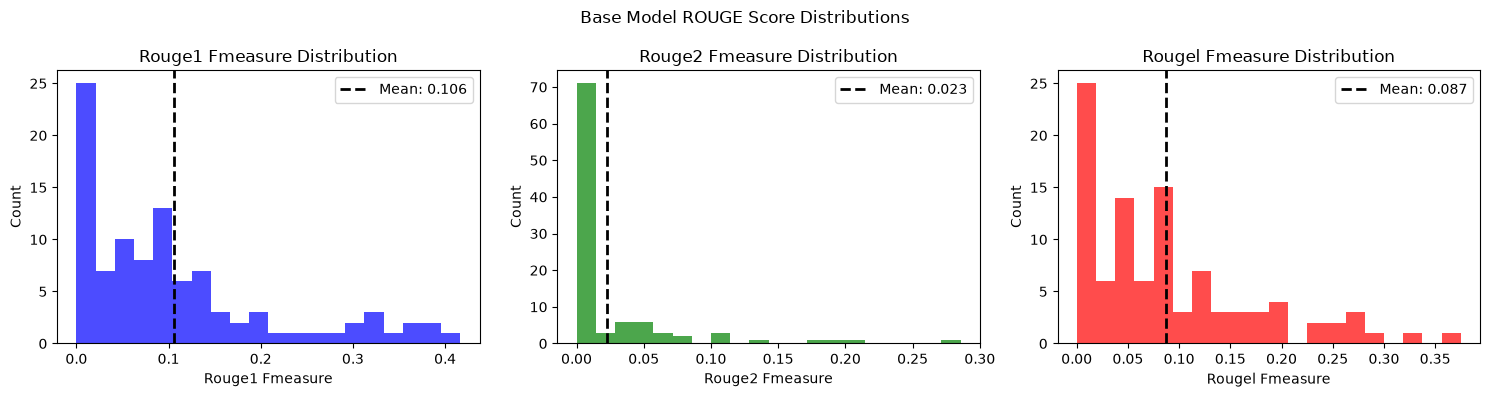

In [23]:
import matplotlib.pyplot as plt

# Create distribution plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = ['rouge1_fmeasure', 'rouge2_fmeasure', 'rougeL_fmeasure']
colors = ['blue', 'green', 'red']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    axes[i].hist(baseline_results[metric], bins=20, alpha=0.7, color=color)
    axes[i].axvline(baseline_results[metric].mean(), color='black',
                   linestyle='--', linewidth=2,
                   label=f'Mean: {baseline_results[metric].mean():.3f}')
    axes[i].set_xlabel(metric.replace('_', ' ').title())
    axes[i].set_ylabel('Count')
    axes[i].set_title(f'{metric.replace("_", " ").title()} Distribution')
    axes[i].legend()

plt.suptitle('Base Model ROUGE Score Distributions')
plt.tight_layout()
plt.show()

### 🎯 Checkpoint

✅ Check your progress for `Evaluate base model performance` ✅ 

## Task 6: Configure and Launch Fine-Tuning

With a baseline established, it's time to fine-tune. In this task, you will configure and launch a managed fine-tuning job on Vertex AI. The managed service will handle the underlying infrastructure, training loop, and model deployment for you.

**Define model display name and set dataset paths**

In [24]:
tuned_model_display_name = "gemini-flash-wikilingua-summarizer"
training_dataset_uri = f"{BUCKET_URI}/datasets/train/train_gemini.jsonl"
validation_dataset_uri = f"{BUCKET_URI}/datasets/val/val_gemini.jsonl"

print(f"Training data: {training_dataset_uri}")
print(f"Validation data: {validation_dataset_uri}")

Training data: gs://your-tuning-bucket-summarization/datasets/train/train_gemini.jsonl
Validation data: gs://your-tuning-bucket-summarization/datasets/val/val_gemini.jsonl


**Create the tuning job configuration**

In [25]:
# The Gen AI SDK uses specific types for configuration

# Training dataset configuration
training_dataset = {
    "gcs_uri": training_dataset_uri
}

# Validation dataset configuration
validation_dataset = types.TuningValidationDataset(
    gcs_uri=validation_dataset_uri
)

# Create tuning config
# What other parameters might you want to set?
# Consider: epochs, learning_rate_multiplier, adapter_size
tuning_config = types.CreateTuningJobConfig(
    tuned_model_display_name=tuned_model_display_name,
    validation_dataset=validation_dataset,
)

### Launch and monitor the job

In [26]:

print("Launching fine-tuning job...")
print(f"Base model: {base_model}")
print(f"Training samples: ~{train_samples}")
print(f"Validation samples: ~{val_samples}")

# TODO: Call the tune method
tuning_job = client.tunings.tune(
base_model=base_model,
training_dataset=training_dataset,
config=tuning_config
)

print(f"\nTuning job started!")
print(f"Job name: {tuning_job.name}")

Launching fine-tuning job...
Base model: gemini-2.5-flash
Training samples: ~500
Validation samples: ~100


/var/tmp/ipykernel_9202/3537800064.py:7: ExperimentalWarning: The SDK's tuning implementation is experimental, and may change in future versions.
  tuning_job = client.tunings.tune(



Tuning job started!
Job name: projects/711528834207/locations/us-central1/tuningJobs/803811590531973120


### Monitor the tuning progress

In [27]:
# The job will take 15-20 minutes
# Let's create a nice progress monitor

def monitor_tuning_job(job_name):
    """Monitor the progress of a tuning job."""

    # States that indicate the job is still running
    running_states = ["JOB_STATE_PENDING", "JOB_STATE_RUNNING"]

    start_time = time.time()

    while True:
        job = client.tunings.get(name=job_name) # gets current job status
        
        # display status
        elapsed = int(time.time() - start_time)
        print(f"\rStatus: {job.state.name} | Elapsed: {elapsed}s", end="")
        
        # check if complete
        if job.state.name not in running_states:
            break
            
        time.sleep(10)

    print(f"\n\nJob completed with status: {job.state.name}")
    return job

# Start monitoring
print("Monitoring tuning job (this will take ~15-20 minutes)...")
completed_job = monitor_tuning_job(tuning_job.name)

Monitoring tuning job (this will take ~15-20 minutes)...


Status: JOB_STATE_SUCCEEDED | Elapsed: 819s

Job completed with status: JOB_STATE_SUCCEEDED


**Retrieve `tuned_model_endpoint` and `experiment_name`**

This can only be done after the tuning process is complete.

In [28]:

if completed_job.state.name == "JOB_STATE_SUCCEEDED":
    tuned_model_endpoint = completed_job.tuned_model.endpoint
    experiment_name = completed_job.experiment
    
    print(f"✅ Success! Tuned model deployed to: {tuned_model_endpoint}")
    print(f"Experiment tracking: {experiment_name}")
else:
    print(f"❌ Job failed with state: {completed_job.state.name}")
    if hasattr(completed_job.state, 'error'):
        print(f"Error: {completed_job.state.error}")

✅ Success! Tuned model deployed to: projects/711528834207/locations/us-central1/endpoints/1234567890123456789
Experiment tracking: projects/711528834207/locations/us-central1/metadataStores/default/contexts/tuning-experiment-20260921115359060612


### 🎯 Checkpoint

✅ Check your progress for `Launch fine-tuning job` ✅ 

## Task 7: Analyze Training Metrics



**Connect to the Vertex AI Experiment Run**

In [29]:
from google.cloud import aiplatform
from google.cloud.aiplatform.metadata import context
from google.cloud.aiplatform.metadata import utils as metadata_utils

# Get the experiment
experiment = aiplatform.Experiment(experiment_name=experiment_name)

# Find the experiment run
filter_str = metadata_utils._make_filter_string(
    schema_title="system.ExperimentRun",
    parent_contexts=[experiment.resource_name]
)
experiment_runs = context.Context.list(filter=filter_str)
experiment_run = experiment_runs[0]

print(f"Found experiment run: {experiment_run.name}")

Found experiment run: tuning-experiment-20260921115359060612-tuning-experiment-run-20260921115359060612


**Read Metrics from the TensorBoard Resource**

In [30]:
# Get TensorBoard resource and construct the full run name
tb_resource = experiment.get_backing_tensorboard_resource()
run_suffix = experiment_run.name.replace(experiment.name, '')[1:]
tb_run_name = f"{tb_resource.resource_name}/experiments/{experiment.name}/runs/{run_suffix}"

# Read the metrics
tensorboard_run = aiplatform.TensorboardRun(tb_run_name)
metrics = tensorboard_run.read_time_series_data()

print("Available metrics:", list(metrics.keys()))

Available metrics: ['/eval_fraction_of_correct_next_step_preds', '/train_num_predictions', '/eval_total_loss', '/eval_num_predictions', '/train_total_loss', '/train_fraction_of_correct_next_step_preds']


**Extract and Visualize Training Metrics**

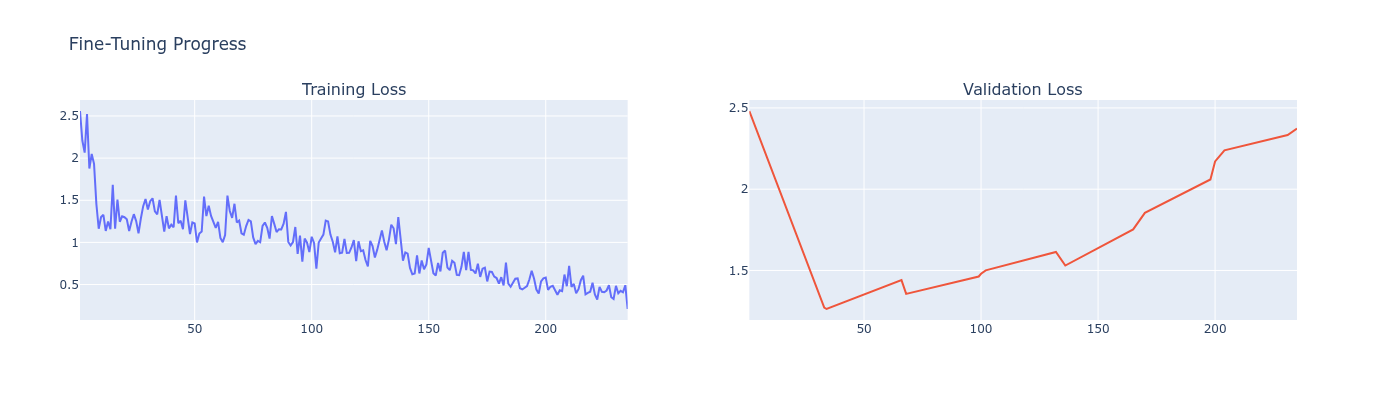

In [31]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

def extract_metric_values(metrics_data, metric_name):
    """Extract steps and values for a specific metric."""
    if metric_name not in metrics_data:
        return [], []
    steps, values = [], []
    for point in metrics_data[metric_name].values:
        steps.append(point.step)
        values.append(point.scalar.value)
    return steps, values

# Extract training and validation loss
train_steps, train_loss = extract_metric_values(metrics, "/train_total_loss")
val_steps, val_loss = extract_metric_values(metrics, "/eval_total_loss")

# Create interactive plots with plotly
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Training Loss", "Validation Loss")
)
fig.add_trace(go.Scatter(x=train_steps, y=train_loss, mode='lines', name='Train'), row=1, col=1)
fig.add_trace(go.Scatter(x=val_steps, y=val_loss, mode='lines', name='Validation'), row=1, col=2)
fig.update_layout(title="Fine-Tuning Progress", showlegend=False, height=400)
fig.show()

### 🎯 Checkpoint

✅ Check your progress for `Analyze tuning metrics` ✅ 

## Task 8. Evaluate the fine-tuned model

This is the final and most important step. Now you will measure how much your fine-tuning improved the model's performance by running the same evaluation process on your new model and comparing the results to the baseline you established in Task 5.

### Qualitative Comparison

In [32]:
# Test the fine-tuned model on the same example used for the baseline
print("Testing fine-tuned model on first example...")
tuned_response = client.models.generate_content(
    model=tuned_model_endpoint,
    contents=test_doc,
    config=generation_config
).text

# Compare all three versions
print("\n" + "="*50 + "\n")
print("REFERENCE summary:")
print(reference_summary)
print("\n" + "-"*30 + "\n")
print("BASE MODEL summary:")
print(response)  # From Task 4
print("\n" + "-"*30 + "\n")
print("FINE-TUNED MODEL summary:")
print(tuned_response)
print("\n" + "="*50 + "\n")

Testing fine-tuned model on first example...


REFERENCE summary:
Squeeze a line of lotion onto the tops of both forearms and the backs of your hands. Place your arms behind your back. Move your arms in a windshield wiper motion.

------------------------------

BASE MODEL summary:
This article describes

------------------------------

FINE-TUNED MODEL summary:
Apply a line of lotion to your forearm. Place both forearms behind your back. Rub your forearms up and down your back.




### Quantitative Comparison

In [33]:
# Run comprehensive evaluation on the tuned model
print("Evaluating fine-tuned model performance...")
tuned_results = evaluate_model(tuned_model_endpoint, test_df, max_samples=100)

Evaluating fine-tuned model performance...


100%|██████████| 100/100 [03:33<00:00,  2.14s/it]


In [34]:
# Calculate and compare statistics
tuned_stats = tuned_results.describe()
tuned_rouge_l = tuned_stats.loc['mean', 'rougeL_fmeasure']

print("\n" + "="*20 + " Results Comparison " + "="*20)
print(f"Baseline ROUGE-L F1 Score: {baseline_rouge_l:.3f}")
print(f"Tuned ROUGE-L F1 Score:    {tuned_rouge_l:.3f}")
print("="*58)

improvement = ((tuned_rouge_l - baseline_rouge_l) / baseline_rouge_l) * 100
print(f"\nImprovement: {improvement:.2f}%")


==================== Results Comparison ====================
Baseline ROUGE-L F1 Score: 0.240
Tuned ROUGE-L F1 Score:    0.238

Improvement: -0.44%


**Visualize the performance comparison**

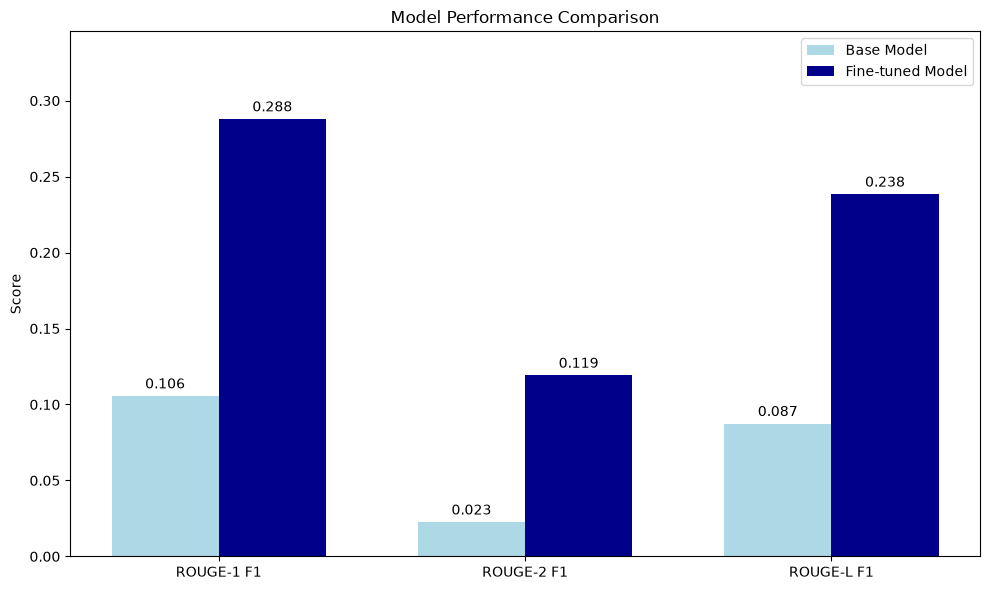

In [35]:
# Create comparison bar chart
metrics = ['ROUGE-1 F1', 'ROUGE-2 F1', 'ROUGE-L F1']
base_scores = [
    baseline_results['rouge1_fmeasure'].mean(),
    baseline_results['rouge2_fmeasure'].mean(),
    baseline_results['rougeL_fmeasure'].mean()
]
tuned_scores = [
    tuned_results['rouge1_fmeasure'].mean(),
    tuned_results['rouge2_fmeasure'].mean(),
    tuned_results['rougeL_fmeasure'].mean()
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, base_scores, width, label='Base Model', color='lightblue')
bars2 = ax.bar(x + width/2, tuned_scores, width, label='Fine-tuned Model', color='darkblue')

ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, max(max(base_scores), max(tuned_scores)) * 1.2)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.tight_layout()
plt.show()


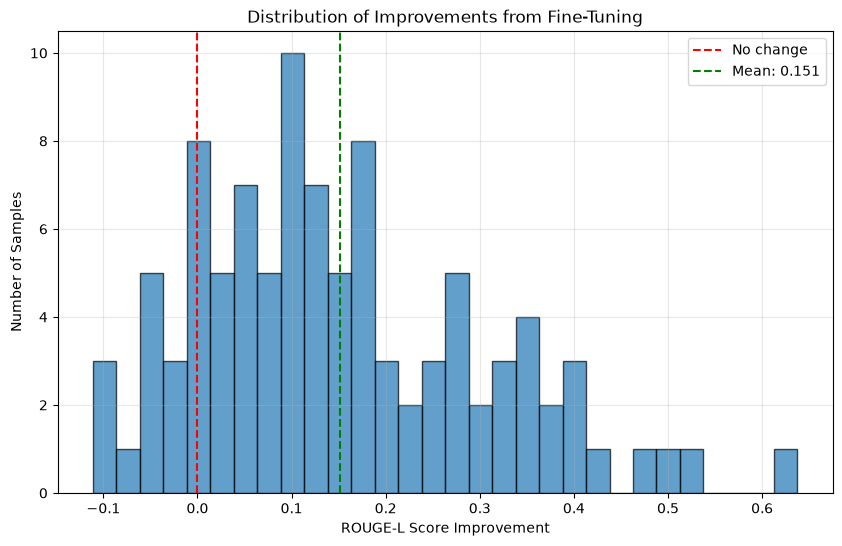

Samples improved: 83 / 99 (83.8%)


In [36]:
# Let's look at the distribution of improvements

# Calculate per-sample improvements
baseline_scores = baseline_results.set_index('idx')['rougeL_fmeasure']
tuned_scores = tuned_results.set_index('idx')['rougeL_fmeasure']

# Which samples improved the most? Which got worse?
common_idx = baseline_scores.index.intersection(tuned_scores.index)
improvements = tuned_scores[common_idx] - baseline_scores[common_idx]

# Visualize the improvement distribution
plt.figure(figsize=(10, 6))
plt.hist(improvements, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', label='No change')
plt.axvline(x=improvements.mean(), color='green', linestyle='--',
            label=f'Mean: {improvements.mean():.3f}')
plt.xlabel('ROUGE-L Score Improvement')
plt.ylabel('Number of Samples')
plt.title('Distribution of Improvements from Fine-Tuning')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Samples improved: {(improvements > 0).sum()} / {len(improvements)} "
        f"({(improvements > 0).mean() * 100:.1f}%)")

### Analyze specific examples 

In [37]:
# Find examples with biggest improvements
improvements_df = pd.DataFrame({
    'idx': common_idx,
    'improvement': improvements
})

best_improvements = improvements_df.nlargest(5, 'improvement')
worst_improvements = improvements_df.nsmallest(5, 'improvement')

print("🎯 Top 5 Most Improved Examples:")
for _, row in best_improvements.iterrows():
    idx = int(row['idx'])
    print(f"\nExample {idx}: +{row['improvement']:.3f} ROUGE-L improvement")
    print(f"Article preview: {test_df.iloc[idx]['input_text'][:100]}...")

print("\n\n⚠️  Bottom 5 Examples (Degraded or Least Improved):")
for _, row in worst_improvements.iterrows():
    idx = int(row['idx'])
    print(f"\nExample {idx}: {row['improvement']:+.3f} ROUGE-L change")
    print(f"Article preview: {test_df.iloc[idx]['input_text'][:100]}...")

🎯 Top 5 Most Improved Examples:

Example 27: +0.637 ROUGE-L improvement
Article preview: Collapsing trachea treatment is either medical (non-surgical) or surgical. Generally, medical manage...

Example 2: +0.537 ROUGE-L improvement
Article preview: Go to https://www.4kdownload.com/products/product-videodownloader in your computer's web browser, th...

Example 31: +0.500 ROUGE-L improvement
Article preview: Depending on your budget and how many keepsakes you will need to purchase, there are many great idea...

Example 63: +0.482 ROUGE-L improvement
Article preview: Work in a well-ventilated area in your home, and mix the bleach and water in a small container. Be c...

Example 5: +0.417 ROUGE-L improvement
Article preview: Usually, rainbows are seen in the rain. That is because there are many water droplets falling throug...


⚠️  Bottom 5 Examples (Degraded or Least Improved):

Example 62: -0.111 ROUGE-L change
Article preview: Inspect the condition of your foundation. If repairs need t

### 🎯 Checkpoint

✅ Check your progress for `Test and evaluate fine-tuned models` ✅ 

## Task 9: Review fine-tuning best practices and considerations

### Document your model with a model card

A key best practice in production machine learning is to document your models. A [model card](https://modelcards.withgoogle.com/) is a short report that provides essential metadata about a model, such as how it was trained, the dataset it used, and its performance metrics. This practice promotes reproducibility, transparency, and makes it easier for teams to manage and understand their models.

In [38]:
# TODO: Create a model card for your tuned model
import json
from datetime import datetime

model_card = {
    "model_name": tuned_model_display_name,
    "base_model": base_model,
    "task": "Article Summarization",
    "dataset": "WikiLingua (English)",
    "training_samples": train_samples,
    "validation_samples": val_samples,
    "metrics": {
        "baseline_rouge_l": float(baseline_rouge_l),
        "tuned_rouge_l": float(tuned_rouge_l),
        "improvement_percent": float(improvement)
    },
    "training_date": datetime.now().strftime("%Y-%m-%d"),
    "recommended_config": generation_config,
    # TODO: Add any other relevant information
    "notes": "Fine-tuned for WikiLingua-style article summarization"
}

# Save for documentation
with open('model_card.json', 'w') as f:
    json.dump(model_card, f, indent=2)

print("Model card created!")
print(json.dumps(model_card, indent=2))

Model card created!
{
  "model_name": "gemini-flash-wikilingua-summarizer",
  "base_model": "gemini-2.5-flash",
  "task": "Article Summarization",
  "dataset": "WikiLingua (English)",
  "training_samples": 500,
  "validation_samples": 100,
  "metrics": {
    "baseline_rouge_l": 0.23953901190808397,
    "tuned_rouge_l": 0.2384880155341468,
    "improvement_percent": -0.43875791486542753
  },
  "training_date": "2026-09-21",
  "recommended_config": {
    "temperature": 0.1,
    "max_output_tokens": 194,
    "top_p": 0.8
  },
  "notes": "Fine-tuned for WikiLingua-style article summarization"
}



### Cost considerations
Fine-tuning involves both an initial training cost and ongoing inference costs. Before starting a project, it's a best practice to estimate the potential return on investment. A well-tuned model can often reduce inference costs by allowing you to use simpler prompts.

In [39]:
# Rough cost estimates
TRAINING_COST_PER_HOUR = 5.00  # USD, approximate
training_duration_hours = 20 / 60  # 20 minutes

estimated_training_cost = TRAINING_COST_PER_HOUR * training_duration_hours
print(f"Estimated fine-tuning cost: ${estimated_training_cost:.2f}")

# Inference cost comparison
QUERIES_PER_DAY = 1000
COST_PER_1K_CHARS = 0.00025  # Example rate

# Base model needs longer prompts
base_prompt_chars = 500  # "Please summarize the following article..."
tuned_prompt_chars = 0   # Just send the article

savings_per_query = (base_prompt_chars / 1000) * COST_PER_1K_CHARS
monthly_savings = savings_per_query * QUERIES_PER_DAY * 30

print(f"\nMonthly prompt savings: ${monthly_savings:.2f}")
print(f"Break-even point: {estimated_training_cost / monthly_savings:.1f} months")

Estimated fine-tuning cost: $1.67

Monthly prompt savings: $3.75
Break-even point: 0.4 months


 

### Key takeaways

- **Evaluation is Essential**: The most important lesson is to measure performance. By establishing a baseline and using quantitative metrics like ROUGE, you can prove that fine-tuning provided a real, measurable improvement.
- **Data Quality is King**: High-quality, clean, and consistent training data is the single most important factor for a successful fine-tuning job.
- **Fine-Tuning Aligns the Model**: A successful job improves model performance on a specific task, resulting in outputs that are more consistent and better aligned with your desired style and focus.
- **It's a Strategic Choice**: Fine-tuning is a powerful tool, but it's a strategic decision that depends on your specific use case, data availability, and cost constraints.


### Next steps and further learning
To continue building on what you've learned, you can:
- **Improve Data Quality**: Add more diverse, high-quality examples to your dataset.
- **Tune Hyperparameters**: Experiment with different training hyperparameters like the number of epochs or the learning rate.
- **Implement Human Evaluation**: Combine quantitative metrics like ROUGE with qualitative feedback from human reviewers.

For more in-depth information, refer to these resources:
- [Vertex AI Documentation](https://cloud.google.com/vertex-ai/docs)
- [Gemini Model Guide](https://cloud.google.com/vertex-ai/docs/generative-ai/model-reference/gemini)
- [Fine-tuning Best Practices](https://cloud.google.com/vertex-ai/docs/generative-ai/models/tune-models)
- [ROUGE Metric Paper](https://www.aclweb.org/anthology/W04-1013/)
- [Google AI Blog on Fine-tuning](https://ai.googleblog.com/)
